In [1]:
import sys
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score ,recall_score ,precision_score,confusion_matrix
sys.path.append(str(Path("..")))
from src.dataset import train_data, train_loader,train_path,train_indices,val_indices, val_loader, ood_loader,ood_path
from torchvision import transforms,datasets
from torch.utils.data import Subset,DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

torch.Size([32, 3, 256, 256])
torch.Size([32])
tensor([3, 3, 1, 2, 5, 7, 3, 2, 5, 5])


In [2]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

CUDA available: True
Device count: 1
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Capability: (8, 6)


In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


print(device)

cuda


In [4]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.RandomApply([
        transforms.GaussianBlur(
            kernel_size=3,
            sigma=(0.1, 2.0)
        )
    ], p=0.2),
    transforms.ColorJitter(
    brightness=0.2,
    contrast=0.2,
    saturation=0.2,
    hue=0.05
        ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_data_aug = datasets.ImageFolder(train_path,transform=train_transform)
val_data = datasets.ImageFolder(train_path,transform=val_transform)

train_dataset_aug = Subset(train_data_aug,train_indices)
val_dataset = Subset(val_data,val_indices)

train_data_aug_loader = DataLoader(
    train_dataset_aug,
    batch_size= 32,
    shuffle= True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)


In [5]:
class CNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 32 * 32, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        return x
    
    
    
num_classes = len(train_data.classes)

model = CNN(num_classes)
model = model.to(device)



criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)





In [6]:
num_epochs = 100

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

val_f1_scores = []
val_precision_scores = []
val_recall_scores = []

val_f1_scores_by_class = []
val_precision_scores_by_class = []
val_recall_scores_by_class = []

best_val_f1 = 0.0
best_epoch = 0





for epoch in range(num_epochs):


    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_data_aug_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_train_loss / len(train_data_aug_loader)
    train_accuracy = train_correct / train_total

    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    all_val_labels = []
    all_val_predictions = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_val_loss += loss.item()


            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


            all_val_labels.extend(
                labels.cpu().numpy()
            )

            all_val_predictions.extend(
                predicted.cpu().numpy()
            )


    val_loss = (
        running_val_loss /
        len(val_loader)
    )

    val_accuracy = (
        val_correct /
        val_total
    )

    val_f1 = f1_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )

    val_precision = precision_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )

    val_recall = recall_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )


    f1_score_by_class = f1_score(
        all_val_labels,
        all_val_predictions,
        average=None,
        zero_division=0
    )

    precision_by_class = precision_score(
        all_val_labels,
        all_val_predictions,
        average=None,
        zero_division=0
    )

    recall_by_class = recall_score(
        all_val_labels,
        all_val_predictions,
        average=None,
        zero_division=0
    )




    train_losses.append(
        train_loss
    )

    train_accuracies.append(
        train_accuracy
    )

    val_losses.append(
        val_loss
    )

    val_accuracies.append(
        val_accuracy
    )

    val_f1_scores.append(
        val_f1
    )

    val_precision_scores.append(
        val_precision
    )

    val_recall_scores.append(
        val_recall
    )

    val_f1_scores_by_class.append(
        f1_score_by_class
    )

    val_precision_scores_by_class.append(
        precision_by_class
    )

    val_recall_scores_by_class.append(
        recall_by_class
    )


    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val Precision: {val_precision:.4f} | "
        f"Val Recall: {val_recall:.4f} | "
        f"Val Macro F1: {val_f1:.4f}"
    )

    print("Precision by each class:")
    print(precision_by_class)

    print("Recall by each class:")
    print(recall_by_class)

    print("F1 Score by each class:")
    print(f1_score_by_class)
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "../models/baseline_Aug.pth"
        )

        print(
        f"Best model saved! "
        f"Epoch: {best_epoch} | "
        f"Val Macro F1: {best_val_f1:.4f}"
        )

Epoch [1/100] | Train Loss: 1.6327 | Train Acc: 0.4582 | Val Loss: 1.0738 | Val Acc: 0.6096 | Val Precision: 0.5703 | Val Recall: 0.5614 | Val Macro F1: 0.5284
Precision by each class:
[0.37765957 0.6372549  0.64705882 0.74509804 0.546875   0.68992248
 0.91836735 0.        ]
Recall by each class:
[0.8875     0.625      0.22916667 0.34545455 0.76086957 0.8018018
 0.8411215  0.        ]
F1 Score by each class:
[0.52985075 0.63106796 0.33846154 0.47204969 0.63636364 0.74166667
 0.87804878 0.        ]


Best model saved! Epoch: 1 | Val Macro F1: 0.5284


Epoch [2/100] | Train Loss: 0.8689 | Train Acc: 0.6949 | Val Loss: 0.7689 | Val Acc: 0.7219 | Val Precision: 0.7535 | Val Recall: 0.7160 | Val Macro F1: 0.7160
Precision by each class:
[0.90769231 0.9        0.44751381 0.71666667 0.69473684 0.776
 0.95192308 0.63333333]
Recall by each class:
[0.7375     0.60576923 0.84375    0.39090909 0.7173913  0.87387387
 0.92523364 0.63333333]
F1 Score by each class:
[0.8137931  0.72413793 0.58483755 0.50588235 0.70588235 0.8220339
 0.93838863 0.63333333]


Best model saved! Epoch: 2 | Val Macro F1: 0.7160


Epoch [3/100] | Train Loss: 0.6264 | Train Acc: 0.7791 | Val Loss: 0.5870 | Val Acc: 0.7877 | Val Precision: 0.7762 | Val Recall: 0.7922 | Val Macro F1: 0.7765
Precision by each class:
[0.79761905 0.82727273 0.69158879 0.79487179 0.6637931  0.88659794
 0.98947368 0.55813953]
Recall by each class:
[0.8375     0.875      0.77083333 0.56363636 0.83695652 0.77477477
 0.87850467 0.8       ]
F1 Score by each class:
[0.81707317 0.85046729 0.72906404 0.65957447 0.74038462 0.82692308
 0.93069307 0.65753425]


...

Epoch [96/100] | Train Loss: 0.0102 | Train Acc: 0.9969 | Val Loss: 0.8407 | Val Acc: 0.8959 | Val Precision: 0.8927 | Val Recall: 0.8855 | Val Macro F1: 0.8883
Precision by each class:
[0.9382716  0.91509434 0.81372549 0.88888889 0.87096774 0.88235294
 0.98058252 0.85185185]
Recall by each class:
[0.95       0.93269231 0.86458333 0.8        0.88043478 0.94594595
 0.94392523 0.76666667]
F1 Score by each class:
[0.94409938 0.92380952 0.83838384 0.84210526 0.87567568 0.91304348
 0.96190476 0.80701754]


Epoch [97/100] | Train Loss: 0.0270 | Train Acc: 0.9949 | Val Loss: 0.9257 | Val Acc: 0.8781 | Val Precision: 0.8825 | Val Recall: 0.8775 | Val Macro F1: 0.8773
Precision by each class:
[0.97333333 0.94117647 0.688      0.84375    0.89156627 0.9122807
 0.97115385 0.83870968]
Recall by each class:
[0.9125     0.92307692 0.89583333 0.73636364 0.80434783 0.93693694
 0.94392523 0.86666667]
F1 Score by each class:
[0.94193548 0.93203883 0.77828054 0.78640777 0.84571429 0.92444444
 0.95734597 0.85245902]


Epoch [98/100] | Train Loss: 0.0243 | Train Acc: 0.9935 | Val Loss: 0.9158 | Val Acc: 0.8767 | Val Precision: 0.8746 | Val Recall: 0.8755 | Val Macro F1: 0.8747
Precision by each class:
[0.92592593 0.87610619 0.76404494 0.82407407 0.85869565 0.91964286
 0.96190476 0.86666667]
Recall by each class:
[0.9375     0.95192308 0.70833333 0.80909091 0.85869565 0.92792793
 0.94392523 0.86666667]
F1 Score by each class:
[0.93167702 0.9124424  0.73513514 0.81651376 0.85869565 0.92376682
 0.95283019 0.86666667]


Epoch [99/100] | Train Loss: 0.0261 | Train Acc: 0.9935 | Val Loss: 0.8939 | Val Acc: 0.8740 | Val Precision: 0.8685 | Val Recall: 0.8679 | Val Macro F1: 0.8679
Precision by each class:
[0.9382716  0.92156863 0.7755102  0.85576923 0.83516484 0.85123967
 0.97087379 0.8       ]
Recall by each class:
[0.95       0.90384615 0.79166667 0.80909091 0.82608696 0.92792793
 0.93457944 0.8       ]
F1 Score by each class:
[0.94409938 0.91262136 0.78350515 0.8317757  0.83060109 0.88793103
 0.95238095 0.8       ]


Epoch [100/100] | Train Loss: 0.0284 | Train Acc: 0.9942 | Val Loss: 1.0031 | Val Acc: 0.8808 | Val Precision: 0.8822 | Val Recall: 0.8764 | Val Macro F1: 0.8783
Precision by each class:
[0.92682927 0.86086957 0.80232558 0.82300885 0.89655172 0.94339623
 0.91150442 0.89285714]
Recall by each class:
[0.95       0.95192308 0.71875    0.84545455 0.84782609 0.9009009
 0.96261682 0.83333333]
F1 Score by each class:
[0.9382716  0.90410959 0.75824176 0.83408072 0.87150838 0.92165899
 0.93636364 0.86206897]


In [7]:

num_classes = len(train_data.classes)

model = CNN(num_classes)
model = model.to(device)

model.load_state_dict(
    torch.load("../models/baseline_Aug.pth")
)

model = model.to(device)

In [8]:
model.eval()


all_val_labels = []

all_val_predictions = []

all_probabilities = []

all_logits = []

val_correct = 0

val_total = 0


classes = train_data.classes


truck_id = classes.index("kamyun")

truckette_id = classes.index("kamyunet")

van_id = classes.index("vanet")


with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        labels = labels.to(device)


        outputs = model(images)


        probabilities = torch.softmax(outputs,dim=1)

        _, predicted = torch.max(outputs,1)
        
        val_total += labels.size(0)

        val_correct += (predicted == labels).sum().item()


        all_val_labels.extend(labels.cpu().numpy())

        all_val_predictions.extend(predicted.cpu().numpy())

        all_probabilities.extend(probabilities.cpu().numpy())

        all_logits.extend(outputs.cpu().numpy())


val_accuracy = val_correct / val_total


val_precision = precision_score(
    all_val_labels,
    all_val_predictions,
    average="macro",
    zero_division=0
)


val_recall = recall_score(
    all_val_labels,
    all_val_predictions,
    average="macro",
    zero_division=0
)


val_f1 = f1_score(
    all_val_labels,
    all_val_predictions,
    average="macro",
    zero_division=0
)


val_precision_by_class = precision_score(
    all_val_labels,
    all_val_predictions,
    average=None,
    zero_division=0
)


val_recall_by_class = recall_score(
    all_val_labels,
    all_val_predictions,
    average=None,
    zero_division=0
)


val_f1_by_class = f1_score(
    all_val_labels,
    all_val_predictions,
    average=None,
    zero_division=0
)
print(f"val Accuracy: {val_accuracy:.4f}")


print(
    f"val Macro Precision: "
    f"{val_precision:.4f}"
)

print(
    f"val Macro Recall: "
    f"{val_recall:.4f}"
)

print(
    f"val Macro F1: "
    f"{val_f1:.4f}"
)


print("val Precision by class:")
print(val_precision_by_class)

print("val Recall by class:")
print(val_recall_by_class)

print("val F1 by class:")
print(val_f1_by_class)

val Accuracy: 0.9096
val Macro Precision: 0.9110
val Macro Recall: 0.9048
val Macro F1: 0.9074
val Precision by class:
[0.96153846 0.89908257 0.81188119 0.84347826 0.93975904 0.95495495
 0.98076923 0.89655172]
val Recall by class:
[0.9375     0.94230769 0.85416667 0.88181818 0.84782609 0.95495495
 0.95327103 0.86666667]
val F1 by class:
[0.94936709 0.92018779 0.83248731 0.86222222 0.89142857 0.95495495
 0.96682464 0.88135593]


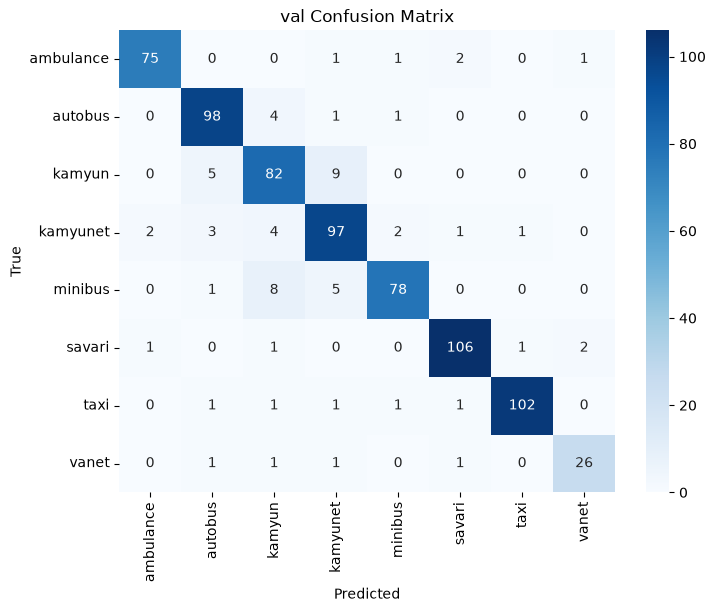

In [9]:
cm = confusion_matrix(
    all_val_labels,
    all_val_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("val Confusion Matrix")

plt.show()

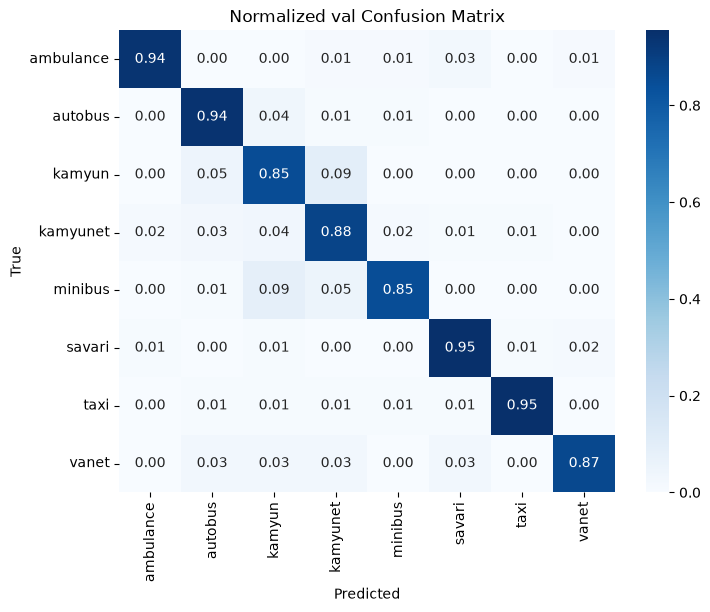

In [10]:
cm_normalized = confusion_matrix(
    all_val_labels,
    all_val_predictions,
    normalize="true"
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=train_data.classes,
    yticklabels=train_data.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized val Confusion Matrix")

plt.show()